# 5.2 UVJ Colour Evolution

This notebook explores the effect of Type 1 and Type 2 AGN on the UVJ colours of host galaxies, corresponding to Section 5.2 of the paper. It includes initial testing on SWIRE templates and comprehensive testing on the GALSEDATLAS template set.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src import config
from glass import data_io, composite_math, photometry, visualization, analysis

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Load Configurations and Models

Loading filters, AGN models, SWIRE templates, and GALSEDATLAS templates.

In [2]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Skirtor')
brown_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Brown', '2014', 'Rest')
swire_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'SWIRE')

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)
swire_templates, swire_names = data_io.read_swire_templates(swire_dir)

## 2. SWIRE Template Evolution (Fig 3)

Generating initial composite modelling using the SWIRE template library and plotting the UVJ evolution.

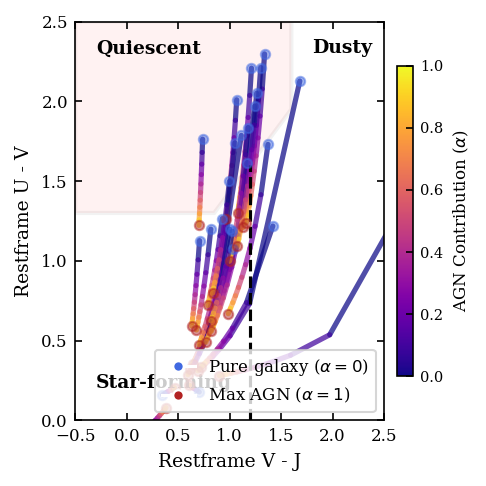

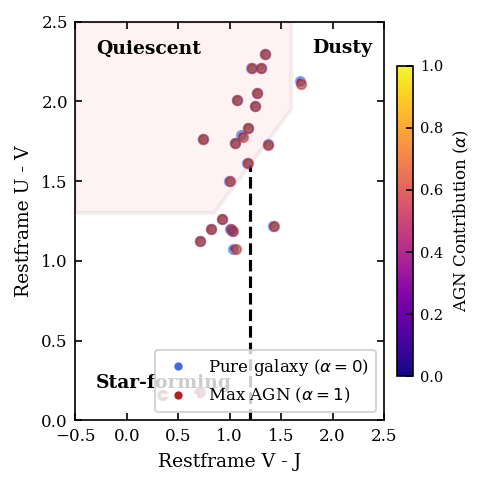

In [3]:
alphas = config.ALPHA_VALUES
swire_results = []

for t_idx, gal_sed in enumerate(swire_templates):
    gal_name = swire_names[t_idx]
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            swire_results.append({'Template': gal_name, 'AGN_Type': agn_name, 'Alpha': alpha, 'U-V': uv, 'V-J': vj})

df_swire_results = pd.DataFrame(swire_results)

def plot_evolution_tracks(df, agn_type, x_col, y_col, plot_func, output_name):
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    subset = df[df['AGN_Type'] == agn_type]

    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=0, vmax=1)

    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        xs = temp_df[x_col].values
        ys = temp_df[y_col].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2],
                    color=cmap(norm(temp_df['Alpha'].iloc[i])),
                    linewidth=2.5, alpha=0.72, solid_capstyle='round')
        ax.scatter(xs[0],  ys[0],  color='royalblue', s=20, zorder=5, alpha=0.5)
        ax.scatter(xs[-1], ys[-1], color='firebrick',  s=20, zorder=5, alpha=0.5)

    plot_func([], [], ax=ax, title="")

    custom_lines = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='royalblue', markersize=5, label=r'Pure galaxy ($\alpha=0$)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='firebrick',  markersize=5, label=r'Max AGN ($\alpha=1$)'),
    ]
    ax.legend(handles=custom_lines, loc='lower right')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'AGN Contribution ($\alpha$)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, output_name), dpi=300, bbox_inches='tight')
    return fig, ax

plot_evolution_tracks(df_swire_results, 'Type1', 'V-J', 'U-V', visualization.plot_uvj_diagram, 'SWIREType1AGNUVJ.pdf')
plot_evolution_tracks(df_swire_results, 'Type2', 'V-J', 'U-V', visualization.plot_uvj_diagram, 'SWIREType2AGNUVJ.pdf')
plt.show()

## 3. GALSEDATLAS Template Evolution (Fig 4 and 5)

Generating comprehensive composite modelling using the larger GALSEDATLAS template library.

Processing Brown template 128/128: UM_461150_SE14
Processed all combinations.


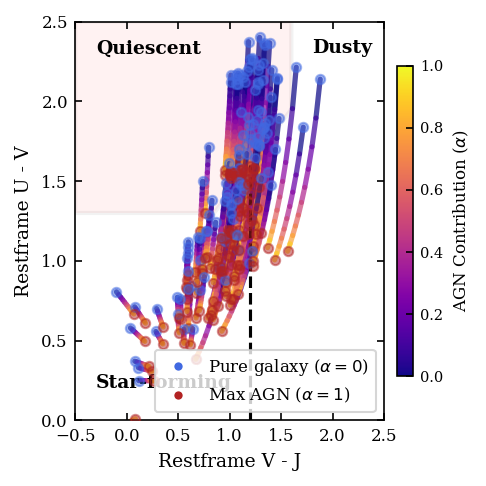

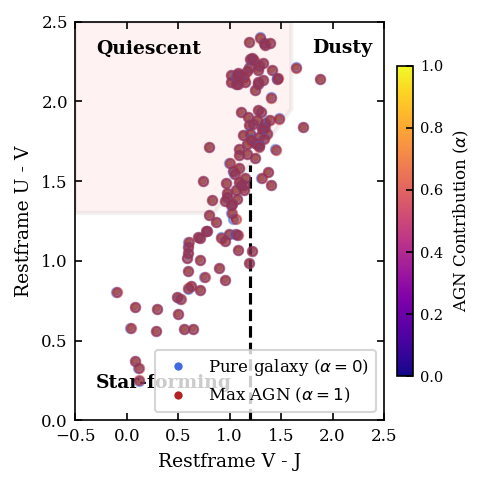

In [4]:
results = []
for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing Brown template {t_idx+1}/{len(brown_templates)}: {gal_name}", end='\r')
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            results.append({'Template': gal_name, 'AGN_Type': agn_name, 'Alpha': alpha, 'U-V': uv, 'V-J': vj})
print("\nProcessed all combinations.")
df_results = pd.DataFrame(results)

plot_evolution_tracks(df_results, 'Type1', 'V-J', 'U-V', visualization.plot_uvj_diagram, 'UVJ_evolution_Type1AGN_Brown.pdf')
plot_evolution_tracks(df_results, 'Type2', 'V-J', 'U-V', visualization.plot_uvj_diagram, 'UVJ_evolution_Type2AGN_Brown.pdf')
plt.show()

## 4. UVJ Population Fraction Analysis

Analyzing how AGN contamination causes galaxies to migrate between the Star-forming, Quiescent, and Dusty regions.

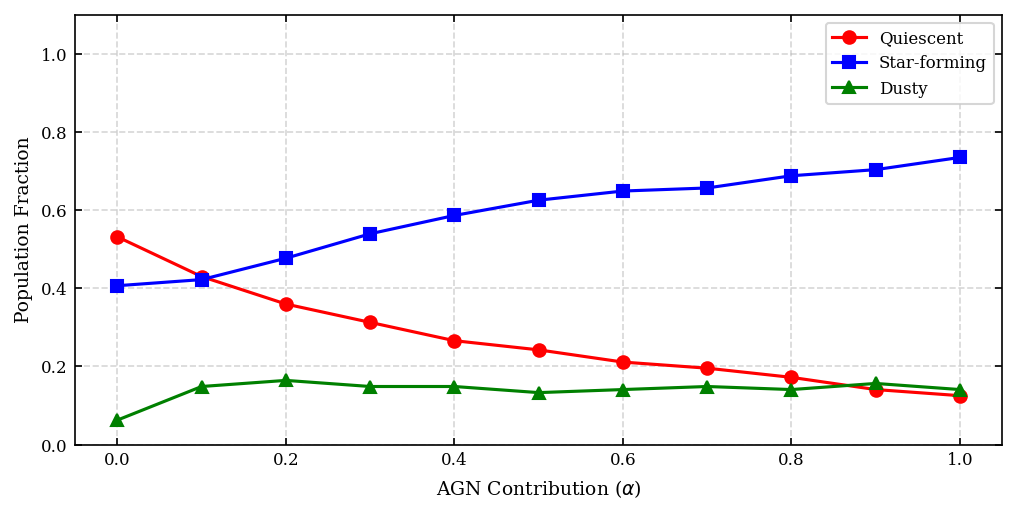

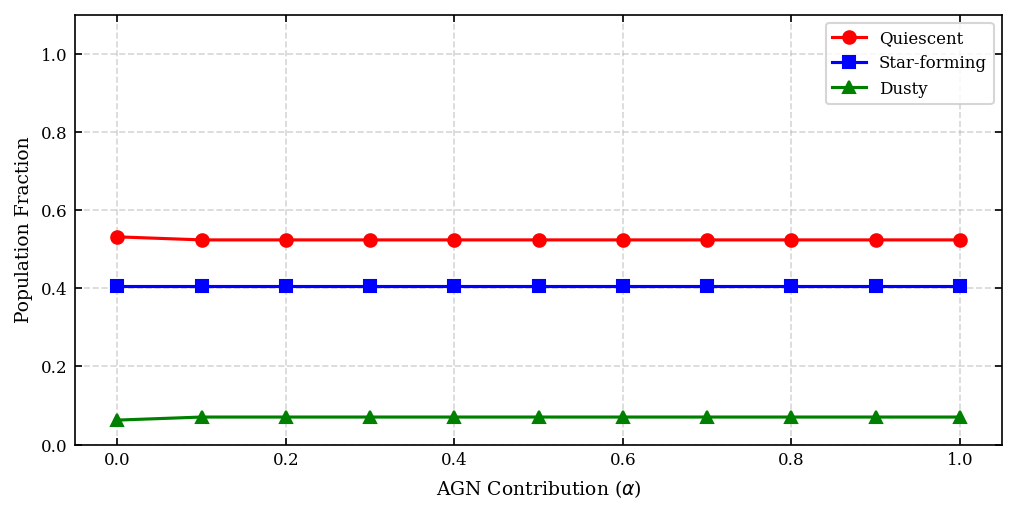

In [5]:
def plot_uvj_fractions(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    alphas = subset['Alpha'].unique()
    q_fracs, sf_fracs, d_fracs = [], [], []

    for alpha in alphas:
        alpha_df = subset[subset['Alpha'] == alpha]
        classifications = photometry.classify_uvj(alpha_df['V-J'], alpha_df['U-V'])
        q, sf, d = analysis.calculate_population_fractions(classifications)
        q_fracs.append(q)
        sf_fracs.append(sf)
        d_fracs.append(d)

    fig, ax = plt.subplots(figsize=visualization.PASA_WIDE)
    ax.plot(alphas, q_fracs,  label='Quiescent',    color='red',   marker='o')
    ax.plot(alphas, sf_fracs, label='Star-forming', color='blue',  marker='s')
    ax.plot(alphas, d_fracs,  label='Dusty',        color='green', marker='^')

    ax.set_xlabel(r'AGN Contribution ($\alpha$)')
    ax.set_ylabel('Population Fraction')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim([0, 1.1])

    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, f'Paper_UVJ_Fractions_{agn_type}.pdf'), dpi=300, bbox_inches='tight')
    plt.show()

plot_uvj_fractions(df_results, 'Type1')
plot_uvj_fractions(df_results, 'Type2')

## 5. Statistical Table 3 (Vector Offsets)

Exporting the vector offset summary to LaTeX for inclusion in the paper.

In [6]:
def calculate_uvj_offsets(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    offsets = []
    for alpha in subset['Alpha'].unique():
        alpha_df = subset[subset['Alpha'] == alpha]
        initial_df = subset[subset['Alpha'] == 0.0]
        vj_alpha, uv_alpha = alpha_df['V-J'].values, alpha_df['U-V'].values
        vj_init, uv_init = initial_df['V-J'].values, initial_df['U-V'].values
        mean_offset = analysis.calculate_mean_vector_offset(vj_alpha, uv_alpha, vj_init, uv_init)
        offsets.append({'Alpha': alpha, 'Mean_Offset': mean_offset})
    return pd.DataFrame(offsets)

off1 = calculate_uvj_offsets(df_results, 'Type1')
off2 = calculate_uvj_offsets(df_results, 'Type2')

table_df = pd.DataFrame({
    r'AGN Contribution (\%)': [int(a*100) for a in alphas],
    'Type 1 Offset (dex)': off1['Mean_Offset'].round(3),
    'Type 2 Offset (dex)': off2['Mean_Offset'].round(3)
})

display(table_df)
table_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.csv'), index=False)
latex_table = table_df.to_latex(index=False, caption=r"Mean vector offset for Type 1 and Type 2 AGN composites in the UVJ diagram.", label="tab:UVJ_vectoroffset")
with open(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.tex'), 'w') as f:
    f.write(latex_table)
print("Exported UVJ Vector Offset table.")

,AGN Contribution (\%),Type 1 Offset (dex),Type 2 Offset (dex)
0,0,0.000,0.000
1,10,0.090,0.000
2,20,0.165,0.000
3,30,0.229,0.001
4,40,0.285,0.001
5,50,0.335,0.001
6,60,0.380,0.001
7,70,0.420,0.002
8,80,0.457,0.002
9,90,0.491,0.002


Exported UVJ Vector Offset table.


## 6. Composite SED Progression (Fig 6)

1D SED progression for representative Star-forming, Quiescent, and Dusty galaxies with increasing Type 1 AGN contribution.

In [ ]:
rep_templates = {
    'Star-forming': 'NGC_0337',
    'Quiescent': 'NGC_4552',
    'Dusty': 'IC_4553'
}
comp_progression_data = {}
for pop_name, gal_name in rep_templates.items():
    if gal_name in brown_names:
        t_idx = brown_names.index(gal_name)
        gal_sed = brown_templates[t_idx]
        comp_progression_data[pop_name] = {}
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_type1, gal_sed, alpha)
            comp_progression_data[pop_name][alpha] = comp_sed

visualization.plot_composite_sed_progression(
    comp_progression_data, filters,
    show_title=True,
    orientation='horizontal',
    figsize=visualization.PASA_SED_WIDE,
    output_path=os.path.join(config.PROCESSED_DATA_DIR, 'CompositeSEDs_UVJ.pdf')
)
plt.show()